# AMDF theo phổ và cao độ — chạy local từ WAV

NAMDF là sai khác biên độ trung bình đã chuẩn hóa trên phần chồng lấp. Praat quyết định hữu thanh và làm mốc cao độ; AMDF chỉ tinh chỉnh cao độ. H42 chọn25/40ms theo tỷ lệ phổ, H43 thêm điều kiện cao độ từng khung. LAB có thống kê cả file và nhãn đoạn, chưa có F0 chuẩn từng thời điểm. Average MAPE là trung bình lỗi phần trăm mean/std/count, không phải lỗi cao độ từng khung. Không đọc test trong notebook.

In [1]:
from pathlib import Path
import sys,json
import numpy as np
import pandas as pd
REPO=Path('C:\\Users\\LAPTOP T&T\\VIOLETTA\\Documents\\ChatGPT\\XLTN\\XLTN-BT2')
HERE=REPO/'research_workbench_2026_10_07'
sys.path.insert(0,str(HERE))
import amdf_dual_window as dual
import amdf_pitch_spectral_controller as reference
import amdf_spectral_controller as spectral
import amdf_anchor as anchor
core,audit=dual.core,dual.audit
items=core.load_training()
by_name={x['file']:x for x in items}
config=json.loads((core.RESULTS/'frozen_config.json').read_text())['models']['AMDF_energy']['config']
families={'H42':spectral,'H43':reference}
receipts={f:json.loads((HERE/f'results/{f}_experiment.json').read_text()) for f in families}
for receipt in receipts.values():
    for relative,expected in receipt['code_sha256'].items():
        assert audit.digest(REPO/relative)==expected,relative
    for file,expected in receipt['data_sha256'].items():
        assert audit.digest(core.TRAIN/file)==expected,file
native_proof=reference.native_api.metadata()
anchor.OUTPUT_PREFIX='spectral_notebook'
anchor.CURVE_CACHE.clear()
for module in families.values():
    module.anchor_api.SOURCE_CACHE.clear()
    module.anchor_api.FEATURE_CACHE.clear()
print('Local Python:',sys.executable,'; Praat',native_proof['version_stdout'],'; NAMDF kernel từ notebook frozen')
display(pd.DataFrame([{'file':x['file'],'fs':x['fs'],**x['stats'],'segment_V_frames':int((x['labels']=='v').sum())} for x in items]))


Local Python: C:\Users\violet\miniconda3\python.exe ; Praat 7.0.02 ; NAMDF kernel từ notebook frozen


file,fs,F0mean,F0std,F0num,segment_V_frames
phone_F1.wav,16000,215.6,20.6,148.0,153
phone_M1.wav,16000,123.7,16.8,232.0,244
studio_F1.wav,44100,229.6,36.8,127.0,123
studio_M1.wav,44100,116.9,26.4,82.0,94


## Tính lại từ WAV

Bốn call Praat mới, NAMDF raw25/40ms và tỷ lệ phổ40ms được tính lại. H24control AMDF được fit chỉ bằng3file khác. Các cấu hình H42/H43 đã đăng ký, không thêm grid. Source cells được commit/push trước replay; output sẽ được verifier đối chiếu sau chạy.

In [2]:
fresh_source_calls={}
for item in items:
    fs,audio=core.load_audio(core.TRAIN/item['file'])
    times,gate,call=reference.native_api.pitch(core.TRAIN/item['file'],'filtered',.3)
    fresh_source_calls['praat7_filtered_v0.3|'+item['file']]=call
    data,curve_proofs={},{}
    for window in (25,40):
        evidence=anchor.curves(item,audio,times,gate,window)
        data[window]=dict(np.load(HERE/evidence['path'],allow_pickle=False))
        curve_proofs[str(window)]={'path':evidence['path'],'sha256':evidence['sha256']}
    ratios=np.full(len(times),np.nan)
    frame_hashes=np.full(len(times),'',dtype='<U64')
    length=int(data[40]['frame_samples'])
    import hashlib
    for i in np.flatnonzero((gate>=70)&(gate<=400)):
        start=int(data[40]['starts'][i])
        if 0<=start and start+length<=len(audio):
            frame=np.ascontiguousarray(audio[start:start+length],dtype=np.float64)
            frame_hashes[i]=hashlib.sha256(frame.tobytes()).hexdigest()
            ratios[i]=reference.anchor_api.high_frequency_ratio(frame,fs)
    spectral_path=HERE/f'results/spectral_notebook_spectral_{Path(item["file"]).stem}.npz'
    assert not spectral_path.exists(),'Preserve completed replay features'
    np.savez_compressed(spectral_path,times=times,gate_frequency=gate,ratio=ratios,
                        starts=data[40]['starts'],frame_samples=length,frame_sha256=frame_hashes,fs=fs)
    for module in families.values():
        rule=module.anchor_api
        rule.SOURCE_CACHE[('praat7_filtered_v0.3',item['file'])]=(times,gate,call)
        rule.FEATURE_CACHE[item['file']]={'data':data,'times':times,'gate':gate,'ratio':ratios,
            'proof':{'path':str(spectral_path.relative_to(HERE)),'sha256':audit.digest(spectral_path),
                     'curve_paths':curve_proofs,'H41_experiment_sha256':audit.digest(HERE/'results/H41_experiment.json'),
                     'rule_sha256':audit.digest(rule.__file__)}}
print('Recomputed 4 fresh Praat source groups, 8 raw NAMDF curve groups and 4 spectral feature groups.')
registries={f:json.loads((HERE/f'{f}_REGISTRY.json').read_text())['options'] for f in families}
features={}
native_calls={}
rows,contour_rows,fit_logs=[],[],[]
columns=['F0mean','F0std','F0num','F0mean_mape','F0std_mape','F0num_mape','average_mape',
         'macro_f1','recall_v','recall_uv','balanced_accuracy','TP','FN','FP','TN','false_voiced_sil']

def feature(module,option,item):
    key=(module.__name__,module.feature_key(option),item['file'])
    if key not in features:
        _,audio=core.load_audio(core.TRAIN/item['file'])
        features[key]=module.extract(item,audio,option)
        if 'native_call' in features[key]:
            native_calls['|'.join(key)]=dict(features[key]['native_call'],historical_native_call=False,new_native_call=False,gate_source='fresh notebook Praat call shared among options')
    return features[key]

def measure(family,module,option,held,split):
    pool=[x for x in items if x['file']!=held['file']]
    native=feature(module,option,held)
    training=[feature(module,option,x) for x in pool]
    pred,f0,fit,_=module.infer(native,training,option,config)
    if module is dual:
        fit=dict(fit,requires_fit=True,actual_fit_files=sorted(x['file'] for x in pool))
    pred,f0,support=module.project(native,held,pred,f0,option['hop_ms'])
    measured=core.score_file(held,pred,f0)
    saved=pd.read_csv(HERE/f'results/{family}_fixed_lofo.csv') if split=='fixed' else pd.read_csv(HERE/f'results/{family}_metrics.csv')
    saved=saved[(saved.option_id==option['id'])&(saved.file==held['file'])]
    if split=='nested':
        saved=saved[(saved.split=='nested')&(saved.model=='candidate')]
    assert len(saved)==1
    assert np.allclose([measured[k] for k in columns],saved.iloc[0][columns].astype(float),atol=1e-8),(family,option['id'],held['file'])
    method=option['id'] if split=='fixed' else family+'_nested'
    rows.append({'evaluation':split,'method':method,'family':family,'option_id':option['id'],**measured})
    fit_logs.append({'evaluation':split,'method':method,'held_file':held['file'],'fit_files':sorted(x['file'] for x in pool),'fitted':fit})
    contour_rows.extend({'evaluation':split,'method':method,'family':family,'file':held['file'],
                        'time_s':float(t),'label':str(lab),'pred_voiced':bool(p),'f0_hz':float(f),'support':bool(s)}
                       for t,lab,p,f,s in zip(held['times'],held['labels'],pred,f0,support))

for held in items:
    measure('H24',dual,dual.registry('H24')[1],held,'fixed')
for family,module in families.items():
    for option in registries[family]:
        for held in items:
            measure(family,module,option,held,'fixed')
display(pd.DataFrame(rows)[['family','option_id','file','average_mape','F0mean_mape','F0std_mape','F0num_mape','false_voiced_sil']])
print('PASS60 fixed rows được tính từ WAV, khớp số liệu đã lưu 1e-8.')


Recomputed 4 fresh Praat source groups, 8 raw NAMDF curve groups and 4 spectral feature groups.
PASS60 fixed rows được tính từ WAV, khớp số liệu đã lưu 1e-8.


family,option_id,file,average_mape,F0mean_mape,F0std_mape,F0num_mape,false_voiced_sil
H24,amdf_gate25_pitch40,phone_F1.wav,8.899895,1.007605,22.313703,3.378378,1
H24,amdf_gate25_pitch40,phone_M1.wav,4.358372,0.257548,2.903775,9.913793,0
H24,amdf_gate25_pitch40,studio_F1.wav,4.545606,0.611076,3.576924,9.448819,0
H24,amdf_gate25_pitch40,studio_M1.wav,5.082710,1.327077,9.043005,4.878049,0
H42,praat7_filtered_v0.3,phone_F1.wav,0.595007,0.257478,0.851866,0.675676,0
H42,praat7_filtered_v0.3,phone_M1.wav,1.015256,1.009207,1.605526,0.431034,0
H42,praat7_filtered_v0.3,studio_F1.wav,1.703844,0.670060,1.291866,3.149606,0
H42,praat7_filtered_v0.3,studio_M1.wav,3.175722,0.412037,5.456594,3.658537,0
H42,amdf_anchor_w25_b200,phone_F1.wav,1.080551,0.233470,2.332506,0.675676,0
H42,amdf_anchor_w25_b200,phone_M1.wav,0.776151,0.988737,0.908681,0.431034,0


## Dùng lựa chọn giữ riêng file đã lưu

Fixed dùng cùng cấu hình cho4file; nested dùng lựa chọn từ3file khác. Notebook replay các lựa chọn đã chốt, không chọn best trên chính file đang chấm. H43fixed170Hz đạt từngfile≤2%, nhưng outerstudio_M1 chọn140Hz vànestedtargetFAIL; không đánh đồng hai kết quả.

In [3]:
for family,module in families.items():
    for selection in receipts[family]['selections']:
        held=selection['outer_held']
        if held=='final':
            continue
        assert held not in selection['selection_files'] and set(selection['selection_files'])==set(by_name)-{held}
        measure(family,module,selection['option'],by_name[held],'nested')
table=pd.DataFrame(rows)
contour_table=pd.DataFrame(contour_rows)
assert len(table)==68
table.to_csv(HERE/'results/spectral_notebook_per_file.csv',index=False)
contour_table.to_csv(HERE/'results/spectral_notebook_contours.csv',index=False)
status=table.query("evaluation=='nested'").groupby('family').average_mape.agg(mean='mean',worst='max',all_files_le_2=lambda x:bool((x<=2).all())).reset_index()
status.to_csv(HERE/'results/spectral_notebook_status.csv',index=False)
display(table.query("evaluation=='nested'")[['family','option_id','file','average_mape','F0std_mape','F0num_mape','macro_f1','false_voiced_sil']])
display(status)
print('Mục tiêu từng file đạt:',bool(status.all_files_le_2.any()))


Mục tiêu từng file đạt: False


family,option_id,file,average_mape,F0std_mape,F0num_mape,macro_f1,false_voiced_sil
H42,amdf_anchor_w25_b200,phone_F1.wav,1.080551,2.332506,0.675676,0.938333,0
H42,amdf_anchor_w25_b200,phone_M1.wav,0.776151,0.908681,0.431034,0.928721,0
H42,amdf_anchor_w25_b200,studio_F1.wav,1.533273,0.554161,3.149606,0.900407,0
H42,amdf_spectral_hf05,studio_M1.wav,2.380001,3.289457,3.658537,0.808446,0
H43,amdf_pitch_spectral_p170,phone_F1.wav,0.340080,0.089632,0.675676,0.938333,0
H43,amdf_pitch_spectral_p170,phone_M1.wav,0.776151,0.908681,0.431034,0.928721,0
H43,amdf_pitch_spectral_p170,studio_F1.wav,1.473576,0.186249,3.149606,0.900407,0
H43,amdf_pitch_spectral_p140,studio_M1.wav,2.523880,3.643256,3.658537,0.808446,0


family,mean,worst,all_files_le_2
H42,1.442494,2.380001,False
H43,1.278422,2.523880,False


## Figures từ phép tính vừa chạy

Mỗi thành phần MAPE chia3, tổng làAverage. Giữ đủ các cấu hình và kết quả không đạt. Ngưỡng phổ/cao độ hiển thị theo registry; chúng không phân loại nam/nữ hoặc thiết bị.

Đã xuất PNG/SVG từ các số liệu vừa tính lại; AMDF window/band ghi trên trục x; gate giữ.


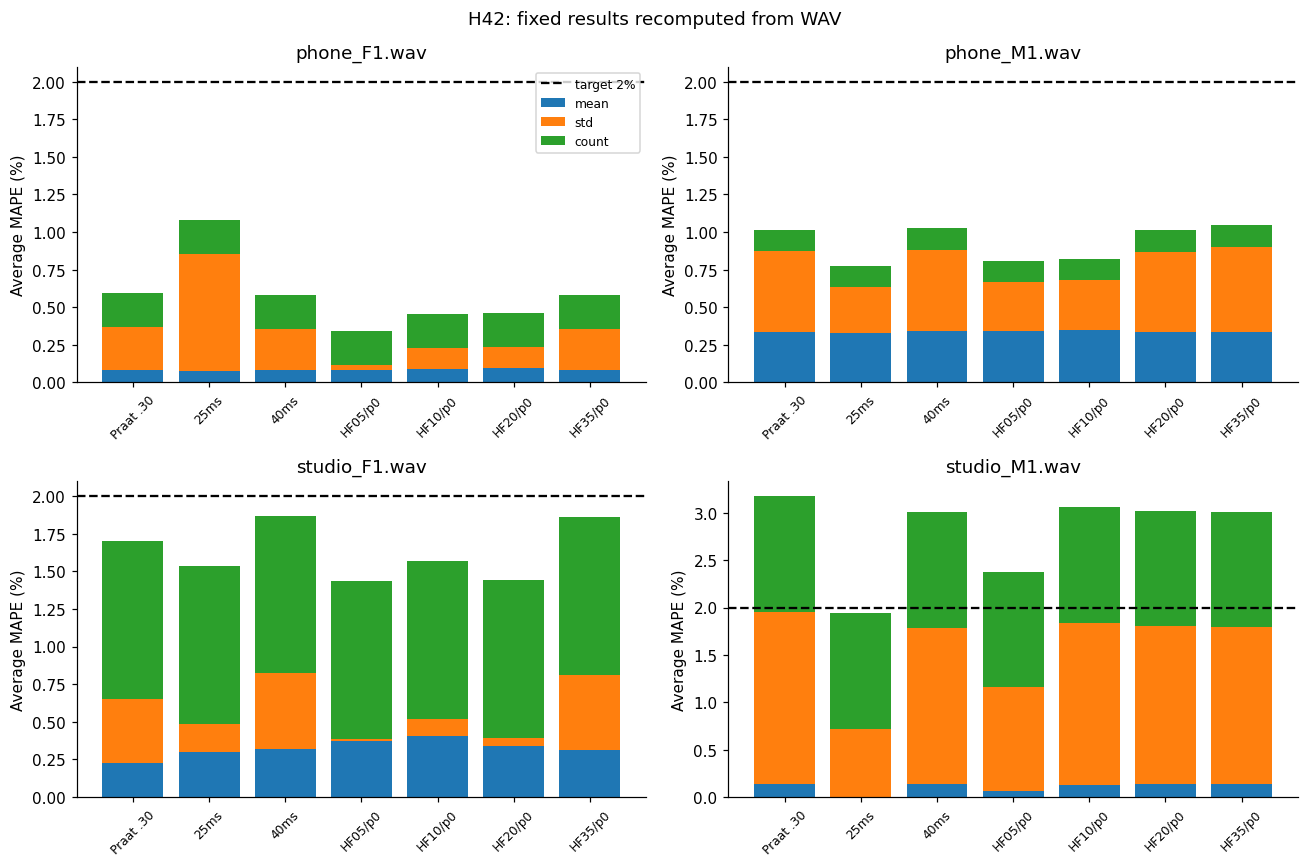

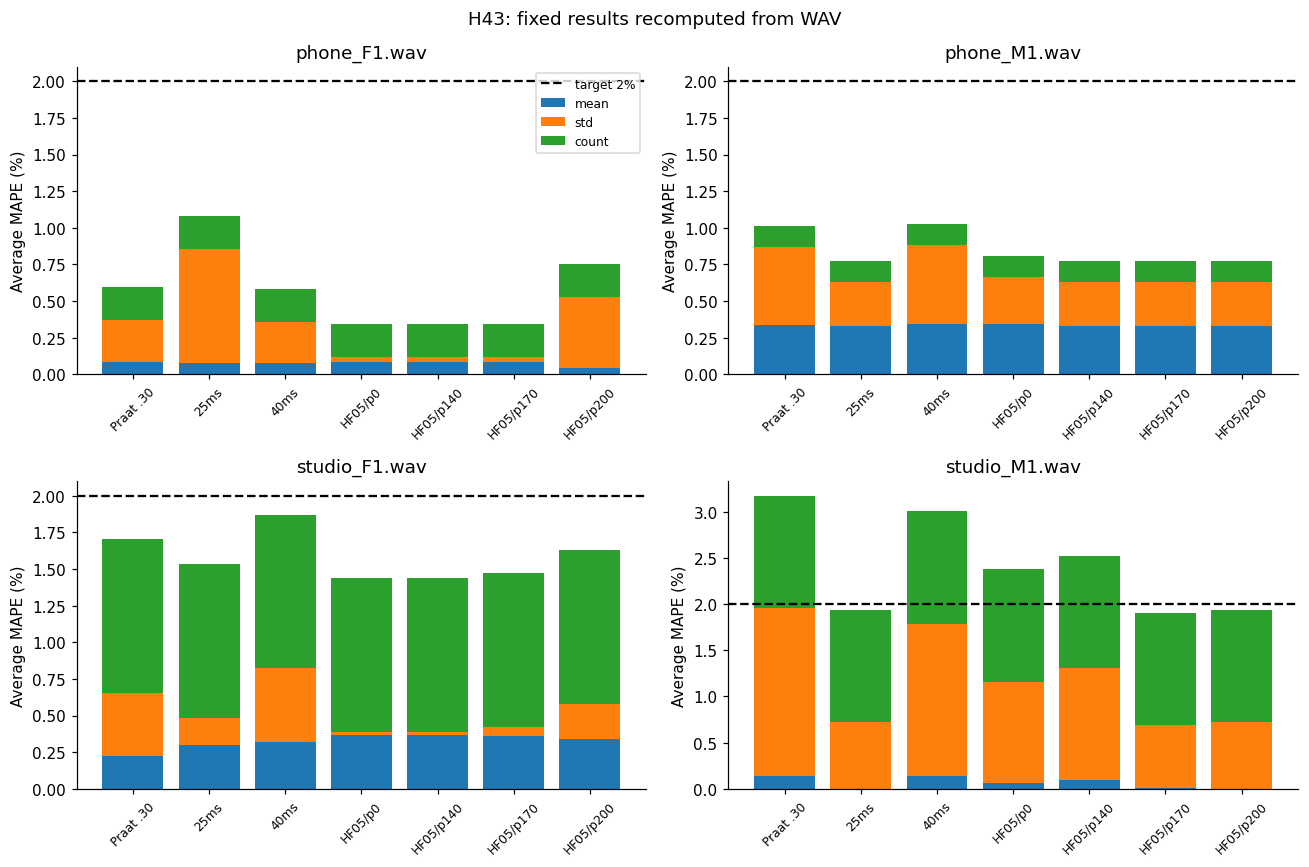

In [4]:
audit.HERE,audit.RESULTS,audit.FIGURES=HERE,HERE/'results',HERE/'figures'
audit.ARTIFACTS.clear()
plot_source=HERE/'results/spectral_notebook_per_file.csv'
for family in families:
    order=[x['id'] for x in registries[family]]
    labels=['Praat .30','25ms','40ms']+[f'HF{int(x["hf_threshold"]*100):02d}/p{x.get("minimum_gate_hz",0)}' for x in registries[family][3:]]
    fixed=table[(table.evaluation=='fixed')&(table.family==family)]
    fig,axes=audit.plt.subplots(2,2,figsize=(12,8))
    for ax,(file,part) in zip(axes.flat,fixed.groupby('file')):
        part=part.set_index('option_id').loc[order]
        bottom=np.zeros(len(order))
        for metric,label in [('F0mean_mape','mean'),('F0std_mape','std'),('F0num_mape','count')]:
            values=part[metric].to_numpy()/3
            ax.bar(labels,values,bottom=bottom,label=label)
            bottom+=values
        assert np.allclose(bottom,part.average_mape)
        ax.axhline(2,color='black',linestyle='--',label='target 2%')
        ax.set(title=file,ylabel='Average MAPE (%)')
        ax.tick_params(axis='x',rotation=45,labelsize=8)
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f'{family}: fixed results recomputed from WAV')
    audit.save_figure(f'spectral_notebook_{family}_components',fig,[plot_source],
                      'Các thành phần mean/std/count cộng thành Average MAPE; mọi cấu hình fixed.',
                      'Không chọn best theo held file; LAB chưa có F0 chuẩn từng khung.')
    display(fig)
    audit.plt.close(fig)
for figure in audit.ARTIFACTS:
    figure.update(generator='build_spectral_notebook.py',generator_sha256=audit.digest(HERE/'build_spectral_notebook.py'),command='python research_workbench_2026_10_07/execute_spectral_notebook.py')
audit.json_write(HERE/'results/spectral_notebook_figure_manifest.json',{'figures':audit.ARTIFACTS})
print('Đã xuất PNG/SVG từ các số liệu vừa tính lại; AMDF window/band ghi trên trục x; gate giữ.')


## Provenance và giới hạn

Python exec nguyên code cell với headlessdisplay, không phải Jupyterkernel. Bốn train đã được dùng nhiều vòng: nested vẫnexploratory. Không sửa nhãn, original/frozen, không tune test, khôngPDF/Drive/deeplearning/MCP retry. ĐọcH42/H43_REPORT.md vàH43_ERROR_ANALYSIS.md để thấy đánh đổi vàselection failure.

In [5]:
source_hashes={str(Path(m.__file__).relative_to(REPO)):audit.digest(m.__file__) for m in (dual,reference,core,audit)}
source_hashes.update({key:value for receipt in receipts.values() for key,value in receipt['code_sha256'].items()})
audit.json_write(HERE/'results/spectral_notebook_provenance.json',{
    'source_sha256':source_hashes,'wav_sha256':{x['file']:audit.digest(core.TRAIN/x['file']) for x in items},
    'native_calls':native_calls,'fit_logs':fit_logs,'praat_native_sha256':native_proof['exe_sha256'],
    'source_calls':fresh_source_calls,'new_actual_Praat_calls':4,'new_curve_groups':8,'new_spectral_groups':4,'test_read':False,'new_grid_or_selection':False})
assert len(native_calls)==56 and len(fit_logs)==68
print('PASS68 measured rows: H24 AMDF control4 + H42/H43 fixed56 + nested8.')
print('4 actual fresh Praat calls/56 derived option groups/8 NAMDF feature groups/4 spectral groups, source/WAV/fit exclusions/contours đã lưu trong provenance; original/frozen giữ.')


PASS68 measured rows: H24 AMDF control4 + H42/H43 fixed56 + nested8.
4 actual fresh Praat calls/56 derived option groups/8 NAMDF feature groups/4 spectral groups, source/WAV/fit exclusions/contours đã lưu trong provenance; original/frozen giữ.


## Nguồn và giới hạn

AMDF_ANCHOR_SOURCE_NOTE.md mapping côngthứcNAMDFfrozen vàgiớihạnISCAabstractAlignedAMDF2006; không đủcôngthứcAAMDFexact, khôngPDF. CitationScientificAgentSkills/K-Denseworkflow đãghi. H41_REPORT.md/H41_REGISTRATION.md giữmetric/gates; nearPraat khôngGT. Pythonexec/headlessdisplay nguyênnămcodecells, khôngJupyterkernel. Khôngtest/Drive/deeplearning/MCP retry hoặc thayfrozen/originalnotebooks.
